# Class 2 - Encoding and Scaling

Yelp Restaurants Module 3 lab notebook. This notebook is organized for GitHub review and uses the final clean dataset produced by `scripts/run_pipeline.py`.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from yelp_lab.config import FINAL_SCHEMA

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "yelp_restaurants_clean.parquet"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "classes"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DISPLAY_DIR = PROJECT_ROOT / ".cache" / "notebook_figures"
NOTEBOOK_DISPLAY_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
_display_counter = 0

def show_and_close():
    global _display_counter
    for number in plt.get_fignums():
        _display_counter += 1
        fig = plt.figure(number)
        display_path = NOTEBOOK_DISPLAY_DIR / f"figure_{_display_counter:03d}.png"
        fig.savefig(display_path, dpi=160, bbox_inches="tight")
        display(Image(filename=str(display_path)))
    plt.close("all")

plt.show = show_and_close

print(df.shape)
df.head()

(5852, 22)


,business_id,state,city,latitude,longitude,dist_from_center,n_categories,price_range_num,has_wifi,has_parking,...,alcohol_num,noise_level_num,hours_open_per_week,n_days_open,review_count,log_review_count,review_velocity,mean_review_length,mean_review_sentiment_score,stars
0,MTSW4McQd7CbVtyjqoe9mw,PA,Philadelphia,39.955505,-75.155564,0.882586,5,1,1,1,...,0,0,94.0,7,80,4.394449,6.374473,558.919540,2.160920,4.0
1,MUTTqe8uqyMdBl186RmNeA,PA,Philadelphia,39.953949,-75.143226,1.879011,3,2,1,1,...,2,2,53.0,6,245,5.505332,60.471854,647.640000,3.772000,4.0
2,ROeacJQwBeh05Rqg7F6TCg,PA,Philadelphia,39.943223,-75.162568,1.066541,2,1,0,1,...,0,1,54.0,6,205,5.327876,25.700947,432.432692,2.533654,4.5
3,QdN72BWoyFypdGJhhI5r7g,PA,Philadelphia,39.939825,-75.157447,1.566801,5,2,1,1,...,2,2,78.0,7,65,4.189655,20.932101,514.275362,2.826087,4.0
4,Mjboz24M9NlBeiOJKLEd_Q,PA,Philadelphia,40.022466,-75.218314,8.990560,4,1,0,0,...,0,2,41.0,6,41,3.737670,7.779351,470.146341,1.000000,3.0


## Goal

Convert messy categorical/business attributes into model-ready numbers and inspect their distributions.

Original PDF tasks:
- Expand nested attributes.
- Build numeric encodings for price, WiFi, parking, credit cards, outdoor seating, alcohol, and noise.
- Scale numeric columns.
- Make 3+ exploratory charts and 1 explanatory chart.

In [2]:
encoded_cols = [
    "price_range_num", "has_wifi", "has_parking", "accepts_credit_cards",
    "outdoor_seating", "alcohol_num", "noise_level_num"
]
df[encoded_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price_range_num,5852.0,1.373889,0.819136,0.0,1.0,1.0,2.0,4.0
has_wifi,5852.0,0.349282,0.476784,0.0,0.0,0.0,1.0,1.0
has_parking,5852.0,0.652597,0.476186,0.0,0.0,1.0,1.0,1.0
accepts_credit_cards,5852.0,0.808612,0.393427,0.0,1.0,1.0,1.0,1.0
outdoor_seating,5852.0,0.323992,0.468037,0.0,0.0,0.0,1.0,1.0
alcohol_num,5852.0,0.514696,0.853250,0.0,0.0,0.0,1.0,2.0
noise_level_num,5852.0,1.284176,1.064845,0.0,0.0,2.0,2.0,4.0


## Exploratory Chart 1 - Price Range Counts

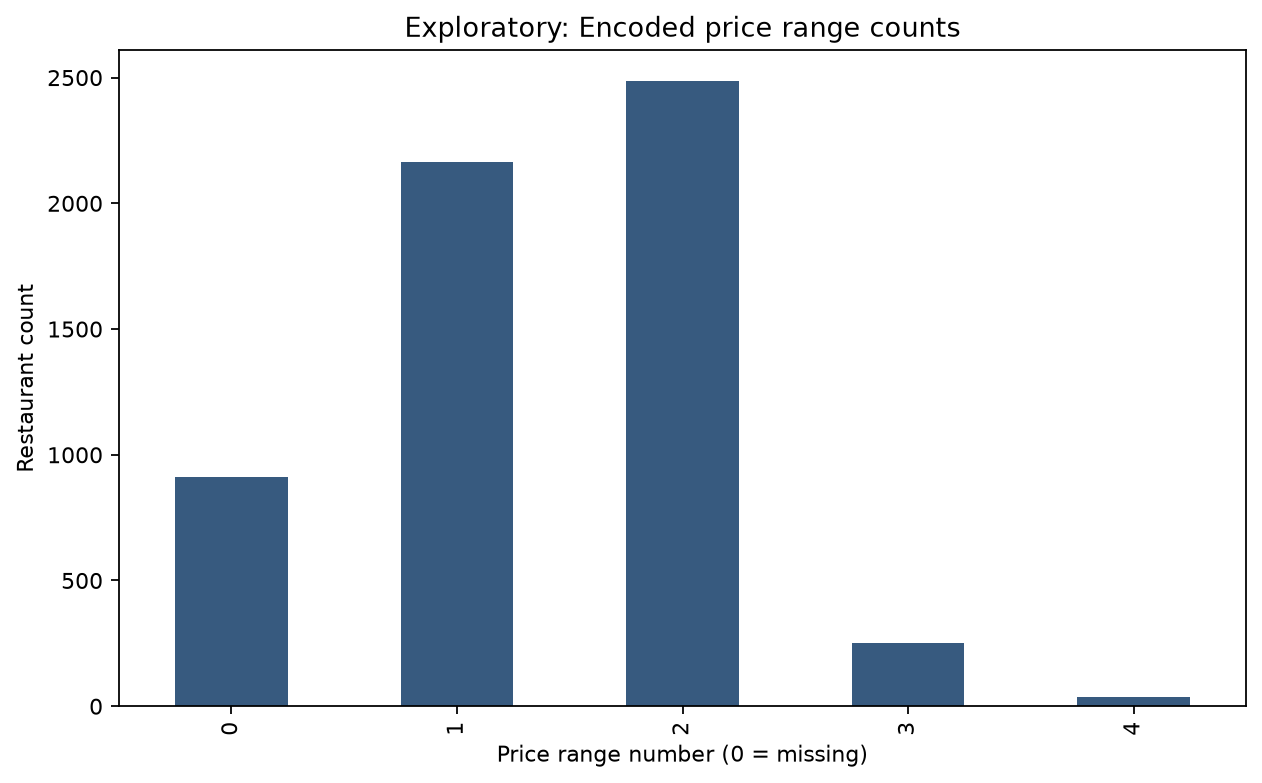

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
df["price_range_num"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#375a7f")
ax.set_title("Exploratory: Encoded price range counts")
ax.set_xlabel("Price range number (0 = missing)")
ax.set_ylabel("Restaurant count")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class2_exploratory_price.png", dpi=160)
plt.show()

## Exploratory Chart 2 - Boolean Attribute Coverage

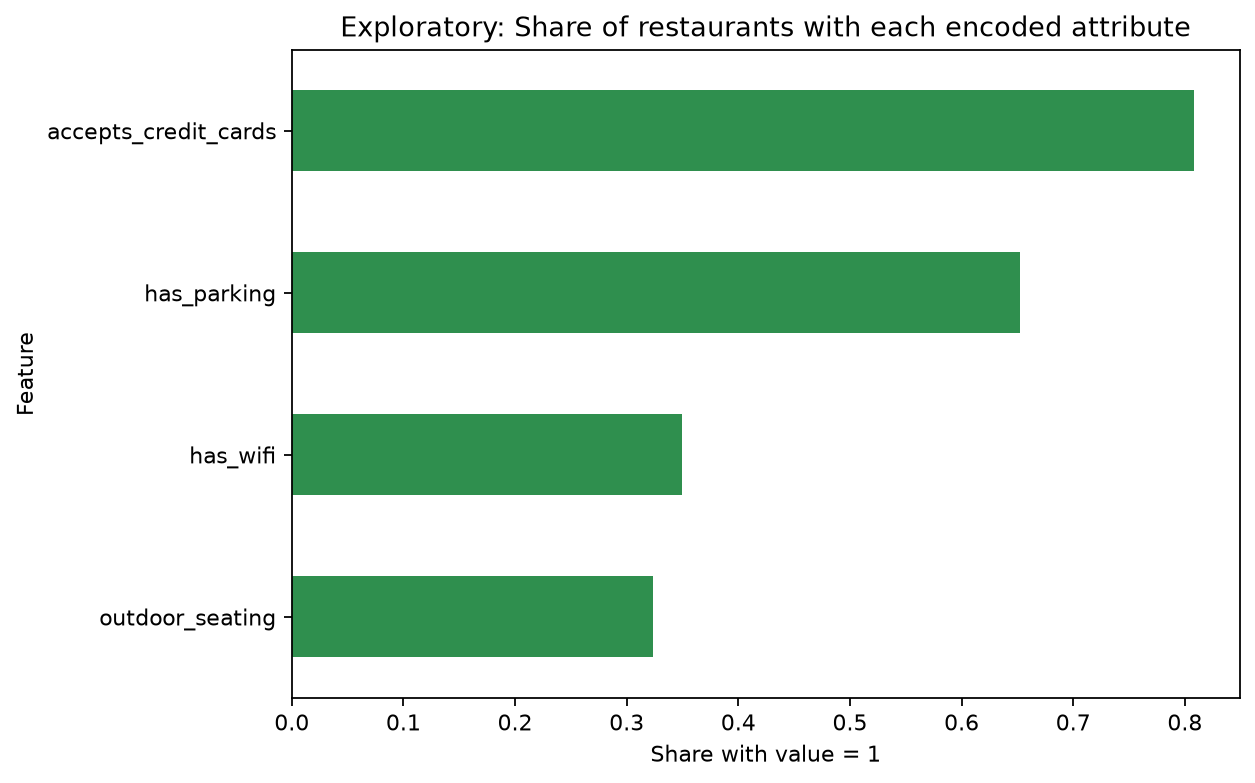

In [4]:
bool_cols = ["has_wifi", "has_parking", "accepts_credit_cards", "outdoor_seating"]
coverage = df[bool_cols].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
coverage.plot(kind="barh", ax=ax, color="#2f8f4e")
ax.set_title("Exploratory: Share of restaurants with each encoded attribute")
ax.set_xlabel("Share with value = 1")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class2_exploratory_attribute_coverage.png", dpi=160)
plt.show()

## Exploratory Chart 3 - Scaled Numeric Features

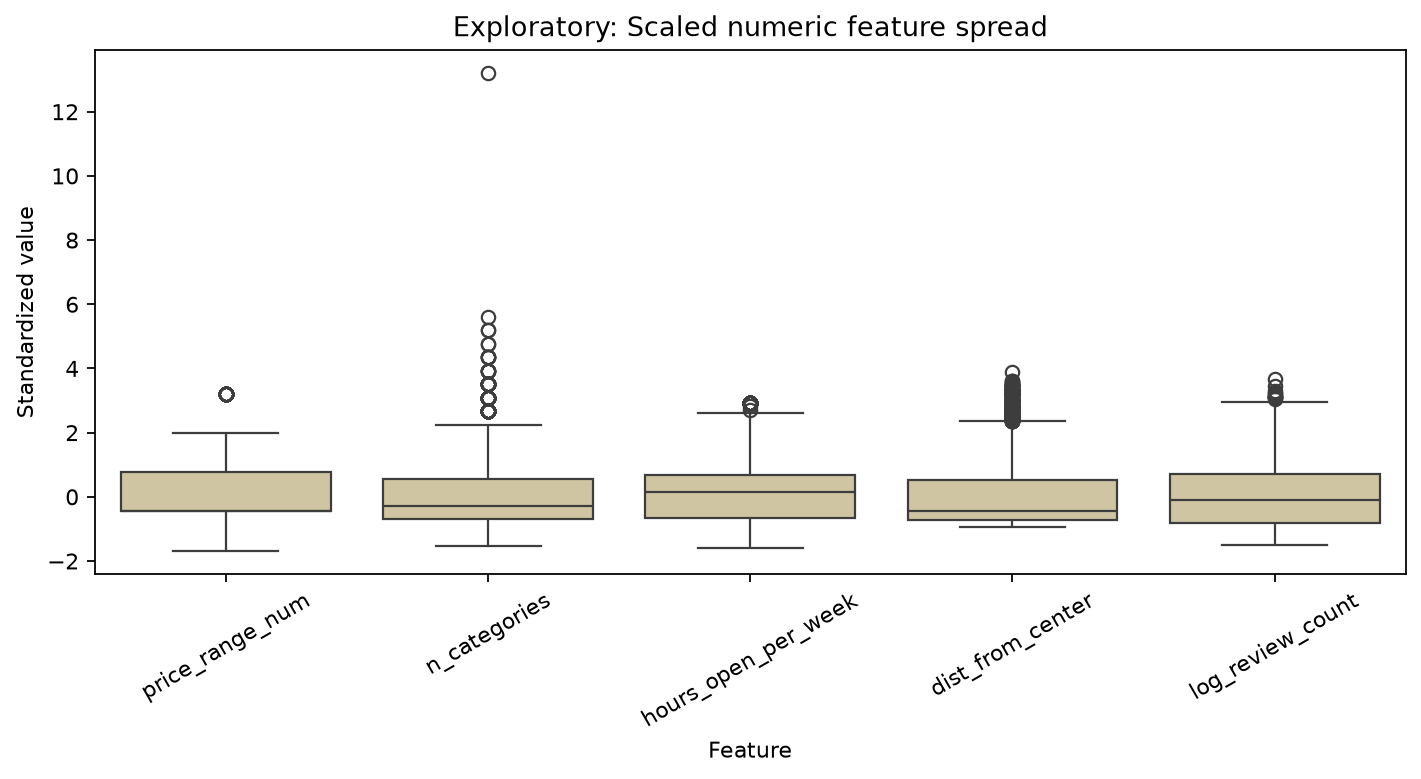

In [5]:
from sklearn.preprocessing import StandardScaler

scale_cols = ["price_range_num", "n_categories", "hours_open_per_week", "dist_from_center", "log_review_count"]
scaled = pd.DataFrame(StandardScaler().fit_transform(df[scale_cols]), columns=scale_cols)
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=scaled, ax=ax, color="#d8c99b")
ax.set_title("Exploratory: Scaled numeric feature spread")
ax.set_xlabel("Feature")
ax.set_ylabel("Standardized value")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class2_exploratory_scaled_features.png", dpi=160)
plt.show()

## Explanatory Chart for Priya - Price Range and Stars

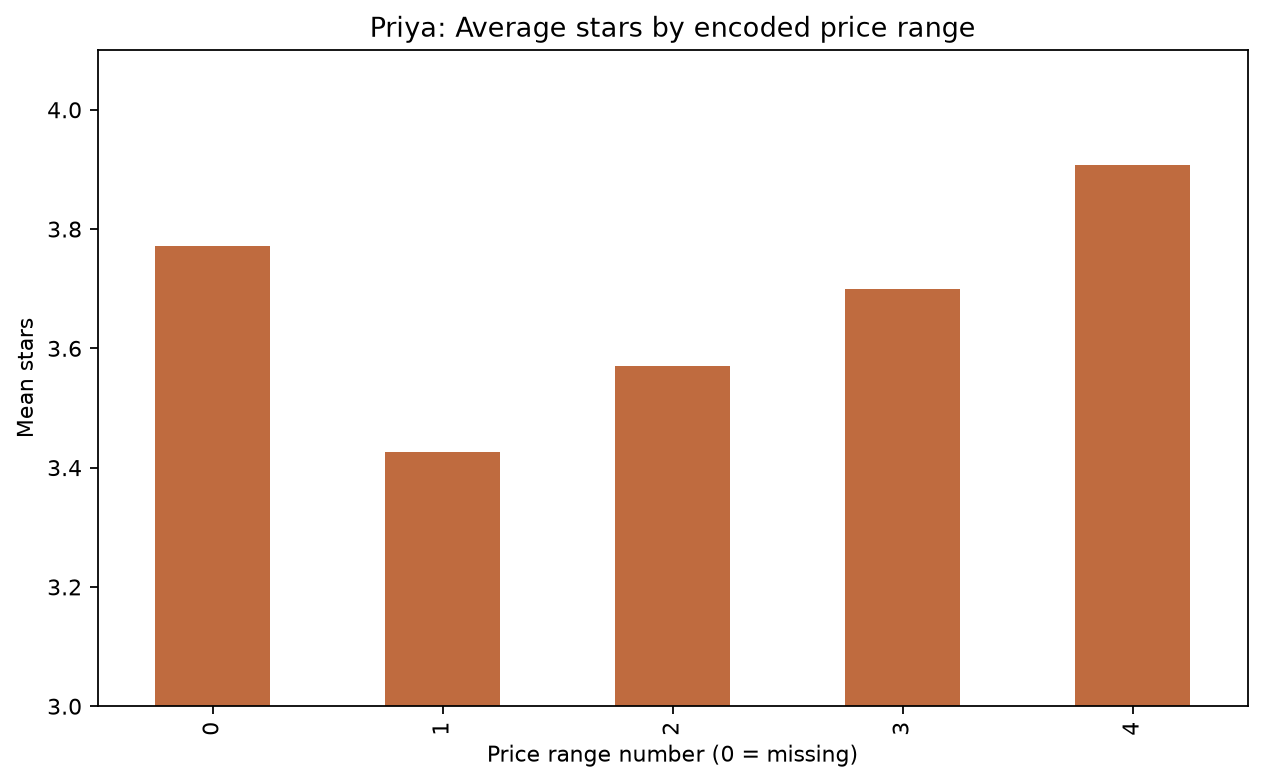

Takeaway: Encoded price is usable as a model feature, but it is not enough by itself to explain ratings.


In [6]:
price_stars = df.groupby("price_range_num")["stars"].mean()
fig, ax = plt.subplots(figsize=(8, 5))
price_stars.plot(kind="bar", ax=ax, color="#bf6b3f")
ax.set_title("Priya: Average stars by encoded price range")
ax.set_xlabel("Price range number (0 = missing)")
ax.set_ylabel("Mean stars")
ax.set_ylim(3.0, 4.1)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class2_explanatory_price_vs_stars.png", dpi=160)
plt.show()
print("Takeaway: Encoded price is usable as a model feature, but it is not enough by itself to explain ratings.")

## Self-Check

- Required attribute encodings exist.
- Missing/unknown values are represented numerically.
- Numeric scaling was demonstrated.
- Price/attribute signals were charted for Priya.